# Demo: análisis exploratorio de logs de honeypot (formato Cowrie / T-Pot)

**Nota importante:** este notebook usa **datos simulados**, generados con el mismo formato de eventos que produce Cowrie (uno de los honeypots que integra T-Pot), ya que todavía no tengo acceso al honeypot real del proyecto. El objetivo es demostrar el tipo de análisis y herramientas descriptos en las secciones 1 y 2 de la entrega, y dar una primera forma concreta al **índice de profundidad de engaño** propuesto en el comentario final.

Herramientas usadas: `pandas` (procesamiento) y `matplotlib` (visualización) — el mismo enfoque descripto en la sección 2 para la Línea 2 del proyecto (análisis con Python), como complemento a lo que en un entorno real haría Kibana.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)

# --- Simulación de eventos estilo Cowrie ---
# Campos reales que genera Cowrie (docs.cowrie.org): eventid, src_ip, session, timestamp, message
paises = ["China", "Rusia", "Brasil", "Estados Unidos", "Vietnam", "India", "Argentina"]
eventos_posibles = [
    "cowrie.session.connect",
    "cowrie.login.failed",
    "cowrie.login.success",
    "cowrie.command.input",
    "cowrie.session.file_download",
    "cowrie.session.closed",
]

# Se genera un conjunto de IPs "atacantes", algunas reincidentes y otras nuevas
ips_frecuentes = [f"185.23.{random.randint(0,255)}.{random.randint(0,255)}" for _ in range(8)]

filas = []
inicio = datetime(2026, 8, 20, 0, 0, 0)

for i in range(3000):
    # 70% de probabilidad de que sea una IP ya conocida (reincidente), 30% una IP nueva
    if random.random() < 0.7:
        ip = random.choice(ips_frecuentes)
    else:
        ip = f"{random.randint(1,223)}.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(0,255)}"

    ts = inicio + timedelta(minutes=random.randint(0, 60*24*5))  # 5 días simulados
    filas.append({
        "timestamp": ts,
        "src_ip": ip,
        "eventid": random.choices(eventos_posibles, weights=[30, 40, 5, 15, 5, 30])[0],
        "pais": random.choice(paises),
        "session": f"s{random.randint(1000,9999)}",
    })

df = pd.DataFrame(filas).sort_values("timestamp").reset_index(drop=True)
print(f"Total de eventos simulados: {len(df)}")
df.head()


Total de eventos simulados: 3000


,timestamp,src_ip,eventid,pais,session
0,2026-08-20 00:00:00,160.102.58.34,cowrie.session.connect,China,s9516
1,2026-08-20 00:04:00,29.226.99.233,cowrie.login.failed,Estados Unidos,s5435
2,2026-08-20 00:05:00,185.23.13.101,cowrie.login.failed,Vietnam,s4300
3,2026-08-20 00:17:00,185.23.114.71,cowrie.session.connect,India,s9552
4,2026-08-20 00:24:00,198.6.104.60,cowrie.login.failed,Rusia,s1514


## 1. IPs de origen más frecuentes

Equivalente a lo que en Kibana se vería como un ranking de atacantes (sección 1: identificación de IPs maliciosas).

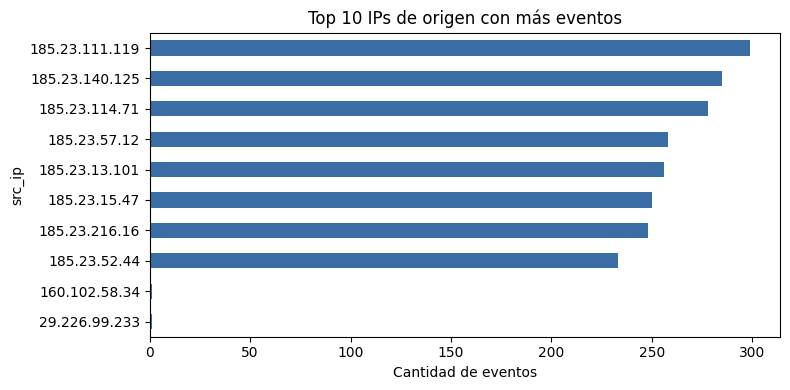

In [2]:
top_ips = df["src_ip"].value_counts().head(10)

plt.figure(figsize=(8,4))
top_ips.plot(kind="barh", color="#3a6ea5")
plt.gca().invert_yaxis()
plt.title("Top 10 IPs de origen con más eventos")
plt.xlabel("Cantidad de eventos")
plt.tight_layout()
plt.show()


## 2. Actividad a lo largo del tiempo

Permite identificar picos de actividad, tal como se describe en la sección 1 (análisis temporal).

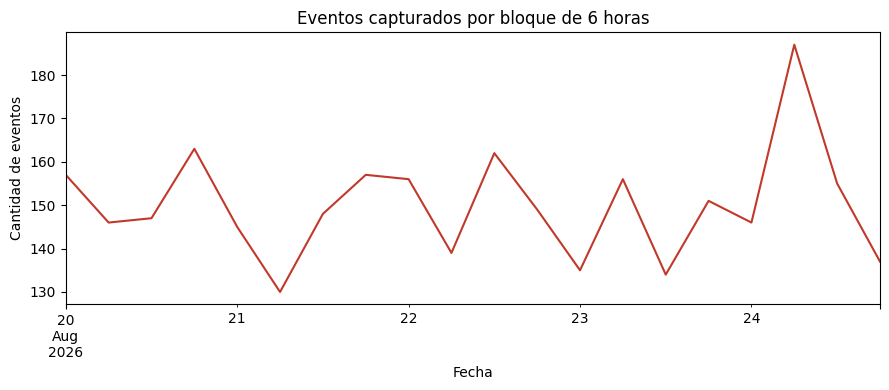

In [3]:
df_hora = df.set_index("timestamp").resample("6h").size()

plt.figure(figsize=(9,4))
df_hora.plot(color="#c0392b")
plt.title("Eventos capturados por bloque de 6 horas")
plt.ylabel("Cantidad de eventos")
plt.xlabel("Fecha")
plt.tight_layout()
plt.show()


## 3. Distribución geográfica de los ataques

Análogo al mapa de ataques que muestra Kibana por defecto en T-Pot (sección 2).

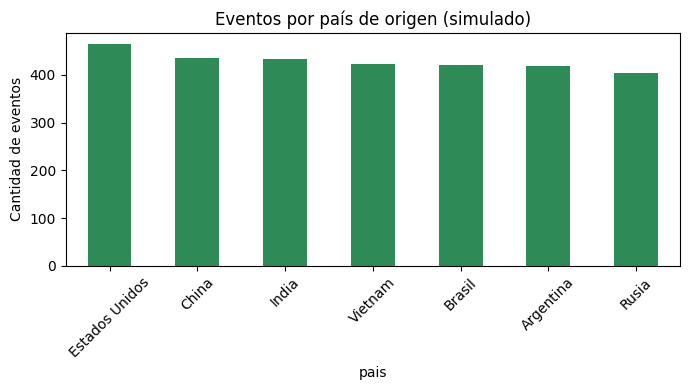

In [4]:
por_pais = df["pais"].value_counts()

plt.figure(figsize=(7,4))
por_pais.plot(kind="bar", color="#2e8b57")
plt.title("Eventos por país de origen (simulado)")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Indicador propuesto: "índice de profundidad de engaño"

Idea central del comentario final: en lugar de medir solo *cuánto* tráfico llega (volumen), medir **qué tan convincente resulta el honeypot** para quien lo ataca. La intuición: si un atacante ejecuta más comandos y permanece más tiempo dentro de una sesión simulada, es porque el engaño lo sostiene mejor (o porque el atacante es más sofisticado y vale la pena seguir de cerca esa sesión).

Para esto se simulan datos a **nivel de sesión** (no de evento suelto): cada sesión de Cowrie tiene una IP, una duración y una cantidad de comandos ejecutados.

In [5]:
# --- Simulación de sesiones completas (para medir profundidad de interacción) ---
sesiones = []
for i in range(600):
    ip = random.choice(ips_frecuentes) if random.random() < 0.7 else \
         f"{random.randint(1,223)}.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(0,255)}"
    inicio_sesion = inicio + timedelta(minutes=random.randint(0, 60*24*5))

    # la mayoría de las sesiones son cortas (bots probando credenciales),
    # una minoría son más profundas (atacante explorando de verdad)
    if random.random() < 0.85:
        duracion = np.random.exponential(scale=8)       # sesiones cortas, en segundos*10
        n_comandos = np.random.poisson(lam=0.5)
    else:
        duracion = np.random.exponential(scale=90)       # sesiones más largas
        n_comandos = np.random.poisson(lam=12)

    sesiones.append({
        "session": f"s{1000+i}",
        "src_ip": ip,
        "inicio": inicio_sesion,
        "duracion_seg": round(duracion, 1),
        "n_comandos": int(n_comandos),
    })

df_sesiones = pd.DataFrame(sesiones).sort_values("inicio").reset_index(drop=True)
df_sesiones["ventana"] = df_sesiones["inicio"].dt.floor("6h")
print(f"Total de sesiones simuladas: {len(df_sesiones)}")
df_sesiones.head()


Total de sesiones simuladas: 600


,session,src_ip,inicio,duracion_seg,n_comandos,ventana
0,s1238,202.189.6.24,2026-08-20 00:05:00,7.1,1,2026-08-20
1,s1440,185.23.216.16,2026-08-20 00:09:00,2.9,1,2026-08-20
2,s1063,73.245.3.25,2026-08-20 00:09:00,5.7,0,2026-08-20
3,s1014,185.23.114.71,2026-08-20 00:11:00,1.0,0,2026-08-20
4,s1096,185.23.13.101,2026-08-20 00:18:00,5.8,2,2026-08-20


In [6]:
indice = df_sesiones.groupby("ventana").agg(
    duracion_promedio=("duracion_seg", "mean"),
    comandos_promedio=("n_comandos", "mean"),
    sesiones=("session", "count"),
).reset_index()

indice.head(10)


,ventana,duracion_promedio,comandos_promedio,sesiones
0,2026-08-20 00:00:00,9.036111,1.222222,36
1,2026-08-20 06:00:00,17.085185,2.333333,27
2,2026-08-20 12:00:00,18.089655,1.206897,29
3,2026-08-20 18:00:00,40.517647,3.588235,34
4,2026-08-21 00:00:00,30.723684,2.789474,38
5,2026-08-21 06:00:00,31.724138,3.172414,29
6,2026-08-21 12:00:00,14.925714,2.685714,35
7,2026-08-21 18:00:00,16.134483,2.034483,29
8,2026-08-22 00:00:00,24.675862,3.517241,29
9,2026-08-22 06:00:00,15.337500,1.625000,24


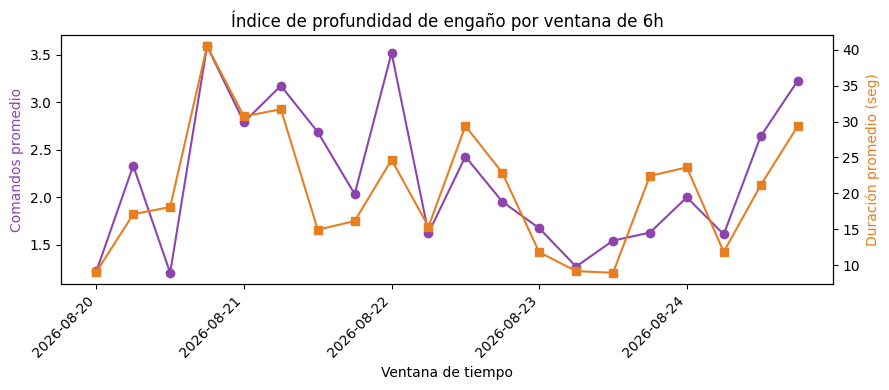

In [7]:
fig, ax1 = plt.subplots(figsize=(9,4))

ax1.plot(indice["ventana"], indice["comandos_promedio"], marker="o", color="#8e44ad", label="Comandos promedio por sesión")
ax1.set_ylabel("Comandos promedio", color="#8e44ad")
ax1.set_xlabel("Ventana de tiempo")

ax2 = ax1.twinx()
ax2.plot(indice["ventana"], indice["duracion_promedio"], marker="s", color="#e67e22", label="Duración promedio (seg)")
ax2.set_ylabel("Duración promedio (seg)", color="#e67e22")

plt.title('Índice de profundidad de engaño por ventana de 6h')
fig.autofmt_xdate(rotation=45)
fig.tight_layout()
plt.show()


**Cómo se interpreta:** una suba sostenida de ambas curvas indica que las sesiones se están volviendo más "profundas" — el atacante interactúa más antes de desconectarse. Esto podría deberse a que el honeypot resulta más convincente, o a que está atrayendo actores más sofisticados que exploran en vez de solo probar credenciales al pasar. Una caída abrupta, en cambio, podría indicar un problema en el sensor o un cambio en el tipo de tráfico recibido.

En producción, este mismo cálculo se haría con una consulta agregada sobre Elasticsearch (agrupando por `session` y `src_ip`), sin necesidad de exportar los datos a pandas.

## Conclusión

Con datos reales de T-Pot, este mismo pipeline (pandas + matplotlib, o su equivalente en Kibana) permitiría automatizar justamente los reportes periódicos que menciona la Línea 1 del proyecto. El índice de profundidad de engaño de la última sección da una primera forma concreta a las "nuevas métricas de salud y efectividad del honeypot" que propone la Línea 2, con un enfoque puesto en la calidad del engaño y no solo en el volumen de tráfico — en línea con el enfoque de *cyber deception* del proyecto 2026.

Como próximo paso, este enfoque podría combinarse con detección de anomalías sobre datos históricos reales, para distinguir automáticamente sesiones de reconocimiento superficial de intentos de explotación más elaborados.